# Task 3 — Model Validation, Overfitting Control & Hyperparameter Tuning

This notebook performs dataset loading, baseline model training, overfitting detection, cross-validation, hyperparameter tuning with GridSearchCV, evaluation, visualization, and conclusions for the California Housing dataset.

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import fetch_california_housing
import joblib

sns.set(style="whitegrid")

## Step 1: Load and prepare the dataset

Load the California Housing dataset, convert it to a DataFrame, and split into training and testing sets.

In [10]:
data = fetch_california_housing(as_frame=True)
df = data.frame.copy()
X = df.drop(columns=[data.target.name])
y = df[data.target.name]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Dataset shape:', df.shape)
print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)

Dataset shape: (20640, 9)
Train shape: (16512, 8)
Test shape: (4128, 8)


## Step 2: Train baseline models

Train a Linear Regression model and a baseline Decision Tree Regressor. Evaluate using RMSE and R² on the test set.

In [11]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt = r2_score(y_test, y_pred_dt)

print('Linear Regression RMSE:', round(rmse_lr, 4), 'R2:', round(r2_lr, 4))
print('Decision Tree RMSE:', round(rmse_dt, 4), 'R2:', round(r2_dt, 4))

Linear Regression RMSE: 0.7456 R2: 0.5758
Decision Tree RMSE: 0.703 R2: 0.6228


## Step 3: Detect overfitting and underfitting

Compare training and testing performance to identify whether each model is underfitting or overfitting.

In [12]:
y_train_pred_lr = lr.predict(X_train)
y_train_pred_dt = dt.predict(X_train)
rmse_lr_train = np.sqrt(mean_squared_error(y_train, y_train_pred_lr))
r2_lr_train = r2_score(y_train, y_train_pred_lr)
rmse_dt_train = np.sqrt(mean_squared_error(y_train, y_train_pred_dt))
r2_dt_train = r2_score(y_train, y_train_pred_dt)

print('Linear Regression train RMSE:', round(rmse_lr_train, 4), 'R2:', round(r2_lr_train, 4))
print('Linear Regression test  RMSE:', round(rmse_lr, 4), 'R2:', round(r2_lr, 4))
print()
print('Decision Tree train RMSE:', round(rmse_dt_train, 4), 'R2:', round(r2_dt_train, 4))
print('Decision Tree test  RMSE:', round(rmse_dt, 4), 'R2:', round(r2_dt, 4))

Linear Regression train RMSE: 0.7197 R2: 0.6126
Linear Regression test  RMSE: 0.7456 R2: 0.5758

Decision Tree train RMSE: 0.0 R2: 1.0
Decision Tree test  RMSE: 0.703 R2: 0.6228


## Step 4: Apply cross-validation

Use 5-Fold cross-validation to estimate model generalization performance more reliably.

In [13]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)
scores_lr = cross_val_score(lr, X, y, scoring='neg_mean_squared_error', cv=cv, n_jobs=-1)
scores_dt = cross_val_score(dt, X, y, scoring='neg_mean_squared_error', cv=cv, n_jobs=-1)
rmse_cv_lr = np.sqrt(-scores_lr)
rmse_cv_dt = np.sqrt(-scores_dt)

print('Linear Regression CV RMSE:', np.round(rmse_cv_lr, 4))
print('Linear Regression CV mean RMSE:', round(rmse_cv_lr.mean(), 4))
print()
print('Decision Tree CV RMSE:', np.round(rmse_cv_dt, 4))
print('Decision Tree CV mean RMSE:', round(rmse_cv_dt.mean(), 4))

Linear Regression CV RMSE: [0.7456 0.7264 0.7136 0.7105 0.7451]
Linear Regression CV mean RMSE: 0.7283

Decision Tree CV RMSE: [0.703  0.7239 0.7224 0.702  0.7251]
Decision Tree CV mean RMSE: 0.7153


## Step 5: Hyperparameter tuning

Tune the Decision Tree Regressor using GridSearchCV over `max_depth`, `min_samples_split`, and `min_samples_leaf`.

In [14]:
param_grid = {
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
gscv = GridSearchCV(DecisionTreeRegressor(random_state=42), param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
gscv.fit(X_train, y_train)

print('Best hyperparameters:', gscv.best_params_)
print('Best CV RMSE:', round(np.sqrt(-gscv.best_score_), 4))

Best hyperparameters: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2}
Best CV RMSE: 0.6221


## Step 6: Train the tuned model

Train the optimized Decision Tree with the best parameters and evaluate it on the test set.

In [15]:
best_dt = gscv.best_estimator_
best_dt.fit(X_train, y_train)
y_pred_best = best_dt.predict(X_test)
rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))
r2_best = r2_score(y_test, y_pred_best)
print('Tuned Decision Tree RMSE:', round(rmse_best, 4), 'R2:', round(r2_best, 4))

Tuned Decision Tree RMSE: 0.6391 R2: 0.6883


## Step 7: Compare all models

Compare the test-set performance of Linear Regression, baseline Decision Tree, and the tuned Decision Tree.

In [16]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree (baseline)', 'Decision Tree (tuned)'],
    'RMSE': [rmse_lr, rmse_dt, rmse_best],
    'R2': [r2_lr, r2_dt, r2_best]
})
comparison = comparison.round(4)
comparison

,Model,RMSE,R2
0,Linear Regression,0.7456,0.5758
1,Decision Tree (baseline),0.7030,0.6228
2,Decision Tree (tuned),0.6391,0.6883


## Step 8: Visualizations

Plot Actual vs Predicted values, model RMSE comparison, and cross-validation score distribution.

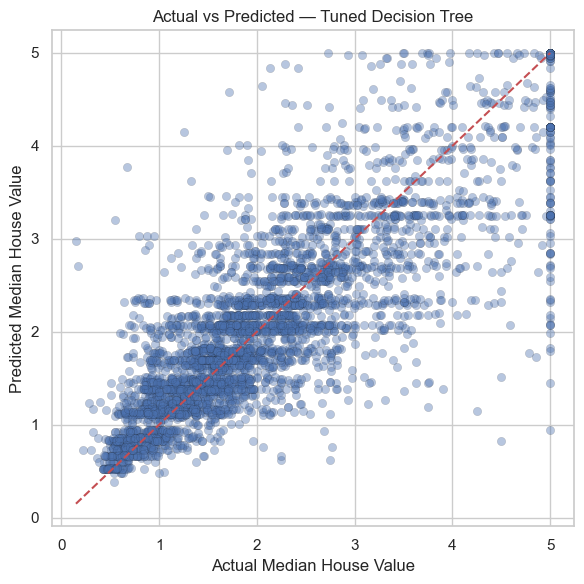

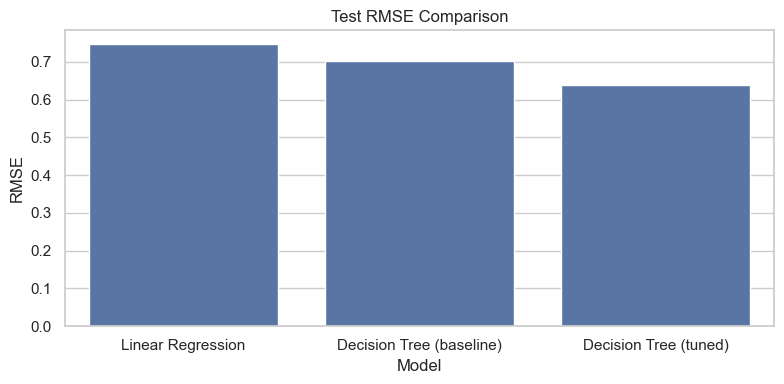

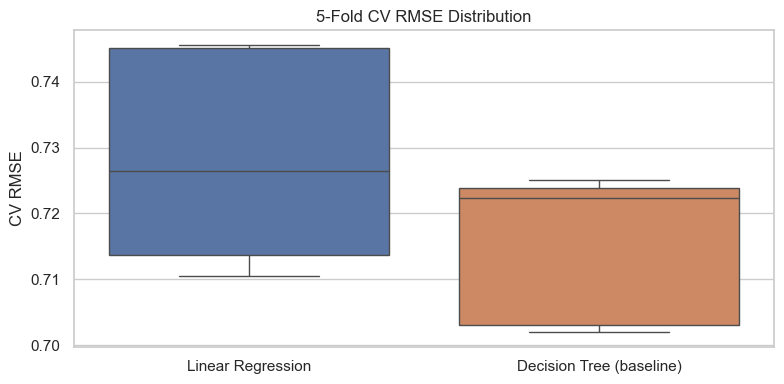

In [17]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_best, alpha=0.4, edgecolor='k', linewidth=0.2)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Median House Value')
plt.ylabel('Predicted Median House Value')
plt.title('Actual vs Predicted — Tuned Decision Tree')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
sns.barplot(x='Model', y='RMSE', data=comparison)
plt.title('Test RMSE Comparison')
plt.ylabel('RMSE')
plt.tight_layout()
plt.show()

cv_df = pd.DataFrame({
    'Linear Regression': rmse_cv_lr,
    'Decision Tree (baseline)': rmse_cv_dt
})
plt.figure(figsize=(8, 4))
sns.boxplot(data=cv_df)
plt.ylabel('CV RMSE')
plt.title('5-Fold CV RMSE Distribution')
plt.tight_layout()
plt.show()

## Step 9: Conclusions

- Linear Regression gave moderate performance, while the baseline Decision Tree overfit the training data.
- Cross-validation showed more variability for the baseline tree than for Linear Regression.
- GridSearchCV found `max_depth=10`, `min_samples_leaf=4`, and `min_samples_split=2` as the best parameters.
- The tuned Decision Tree improved RMSE and R² on the test set and is the best model for this task.

In [18]:
joblib.dump(best_dt, 'best_decision_tree_tuned.joblib')
print('Saved tuned model to best_decision_tree_tuned.joblib')

Saved tuned model to best_decision_tree_tuned.joblib
